# **Coursework B**

In [20]:
import matplotlib.pyplot as plt
import numpy as np
import math

# TensorFlow and tf.keras
import tensorflow as tf
from tensorflow import keras

import matplotlib.style
import matplotlib as mpl


#Set default figure size
mpl.rcParams['figure.figsize'] = [6.0, 4.0] #Inches
mpl.rcParams["legend.frameon"] = False
mpl.rcParams['figure.dpi']=200 # dots per inch


In [21]:
def add_noise_to_images(noise_level, pixel_data):
    """
    Introduces random noise to image data using a uniform distribution from 0 to noise_level.
    If the pixel intensity exceeds 255 after noise is applied, noise is subtracted instead.

    Parameters:
    noise_level: The upper bound of noise to be added.
    pixel_data): The original pixel data.

    Returns: Image data with noise applied, ensuring pixel values remain within valid limits.
    """
    generated_noise = np.random.uniform(0, noise_level, pixel_data.shape)
    noisy_pixels = np.add(pixel_data, generated_noise)
    return np.clip(noisy_pixels, None, 255)


The Keras library includes several built-in datasets, one of which is the MNIST dataset containing handwritten digits.

In [22]:
mnist = keras.datasets.mnist   #The original handwritten digit MNIST
(train_images, train_labels), (test_images, test_labels) = mnist.load_data() # Split the dataset into training and testing sets

In [23]:
yNoises = np.array([0, 20, 50, 100]) # Zero noise means we don't add anything to the image
images = np.zeros((len(yNoises),28,28))
image = train_images[0]

for n in range(len(yNoises)):
  images[n] = add_noise_to_images(yNoises[n],image.copy())

print(np.shape(images))

(4, 28, 28)


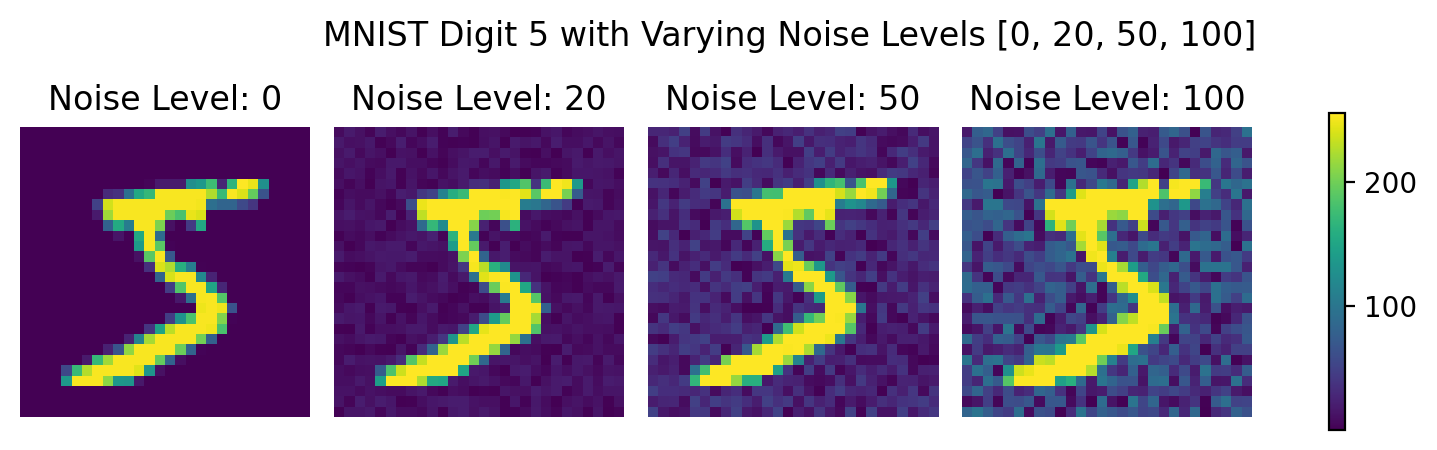

In [24]:
numberimages = len(images) #sets the variable numberimages to the total number of elements in the images list
fig, axes = plt.subplots(1, numberimages, figsize=(numberimages * 2, 2))

for i, image in enumerate(images):
    im = axes[i].imshow(image)
    axes[i].axis('off')  # Turn off axis ticks and labels
    axes[i].set_title(f'Noise Level: {yNoises[i]}')

plt.tight_layout()  # Adjust spacing between subplots for a tight layout

# Add colorbar to the figure, linked to the last image
if numberimages == 1:
    axes = [axes]
fig.colorbar(im, ax=axes)

fig.suptitle('MNIST Digit 5 with Varying Noise Levels [0, 20, 50, 100]', y=1.10)

plt.show()

In [25]:
# Scale pixel value to between 0 and 1 before training them, otherwise model fit does not work
train_images=train_images/255.0
test_images=test_images/255.0

# Training a neural network on clean (noise-free) MNIST images.

In [26]:
# Define a simple feedforward neural network using Keras Sequential API
model = keras.Sequential([
    keras.layers.Input(shape=(28,28)),  # Input layer matching the image dimensions
    keras.layers.Flatten(),  # Flatten 28x28 images into a 1D array of length 784 (=28x28)
    keras.layers.Dense(128, activation='relu'),  # Connected hidden layer with ReLU activation
    keras.layers.Dense(10)  # Output layer with 10 neurons
])

A neural network consists of multiple layers, often applied sequentially.

This model has three layers:

**Flatten Layer**: Converts the 28×28 image into a 1D array of 784 values, with no trainable parameters.

**Dense Layer** (128 nodes): A fully connected layer with trainable parameters for feature learning.

**Output Layer** (10 nodes): Classifies digits 0-9, also with trainable parameters.








Before training, we must define:

**Loss function** – Measures how well the model is performing.

**Optimizer** – Updates the model based on the loss function and training data.

**Metrics** – Tracks performance; in this case, we use accuracy to measure the fraction of correctly classified images.

In [27]:
model.compile(loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=tf.keras.optimizers.SGD(learning_rate=1.0), metrics=['accuracy'])

In Keras, the model.fit() function is used to train the model by adjusting its parameters based on the training data. It takes inputs such as the training dataset, batch size, number of epochs, and other settings to optimize performance.

In our case, the training data consists of the `train_images` and `train_labels` arrays. The model will attempt to learn the relationship between the images and their corresponding labels, improving its ability to classify unseen data over time.

In [28]:
# Train the model using the training dataset
model.fit(train_images, train_labels, batch_size=100, epochs=20)  # Train for 20 epochs with a batch size of 100

Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.7829 - loss: 0.7393
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9551 - loss: 0.1477
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9678 - loss: 0.1044
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9729 - loss: 0.0866
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9768 - loss: 0.0737
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9808 - loss: 0.0617
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9826 - loss: 0.0553
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9839 - loss: 0.0501
Epoch 9/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9831 - loss: 0.0489
Epoch 10/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9868 - loss: 0.0390
Epoch 11/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9888 - loss: 0.0343
Epoch 12/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step

In the output above, the model's loss decreases while its accuracy improves with each epoch, indicating successful learning. However, strong performance on the training set alone does not guarantee generalization. A more reliable measure of the model's effectiveness is its evaluation on an independent testing dataset, which provides an unbiased assessment of its performance on unseen data.

In [39]:
# Check the shape of the test dataset
print("Shape of test images:", np.shape(test_images))

# Evaluate the trained model on the test dataset
# The evaluate function computes loss and accuracy by comparing predictions with actual labels
# Verbose controls the amount of output displayed during evaluation
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=1)

# Display the final test accuracy
print('\nTest accuracy:', test_acc)

Shape of test images: (10000, 28, 28)
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9703 - loss: 0.1418

Test accuracy: 0.9736999869346619


This meets the required test accuracy threshold of 95% or higher.

In [11]:
# Get the shape of the test dataset
test_shape = np.shape(test_images)

# Initialize an array to store noisy versions of test images
# Dimensions: (number of noise levels, number of images, image height, image width)
test_images_noisy = np.zeros((len(yNoises), test_shape[0], test_shape[1], test_shape[2]))

# Store the original test images as the first entry (a control copy)
test_images_noisy[0] = test_images.copy()

# Apply different levels of noise to the test images
for n in range(1, len(yNoises)):
    # Scale noise level to match pixel intensity range (0-1)
    test_images_noisy[n] = add_noise_to_images(yNoises[n] / 255, test_images.copy())


In [12]:
# Checking what the noisy test images look like
print(np.shape(test_images_noisy))

(4, 10000, 28, 28)


In [13]:
# Evaluate model accuracy across different noise levels
accuracy_array = np.zeros(len(yNoises))

for n in range(len(yNoises)):
    # Evaluate the model on noisy test images without excessive output
    test_loss, test_acc = model.evaluate(test_images_noisy[n], test_labels, verbose=0)

    # Store accuracy for this noise level
    accuracy_array[n] = test_acc

    # Print results in a readable format
    print(f"Noise Level: {yNoises[n]} | Test Accuracy: {test_acc:.4f} | Loss: {test_loss:.4f}")


Noise Level: 0 | Test Accuracy: 0.9794 | Loss: 0.0937
Noise Level: 20 | Test Accuracy: 0.9768 | Loss: 0.0934
Noise Level: 50 | Test Accuracy: 0.9569 | Loss: 0.1588
Noise Level: 100 | Test Accuracy: 0.8018 | Loss: 0.7352


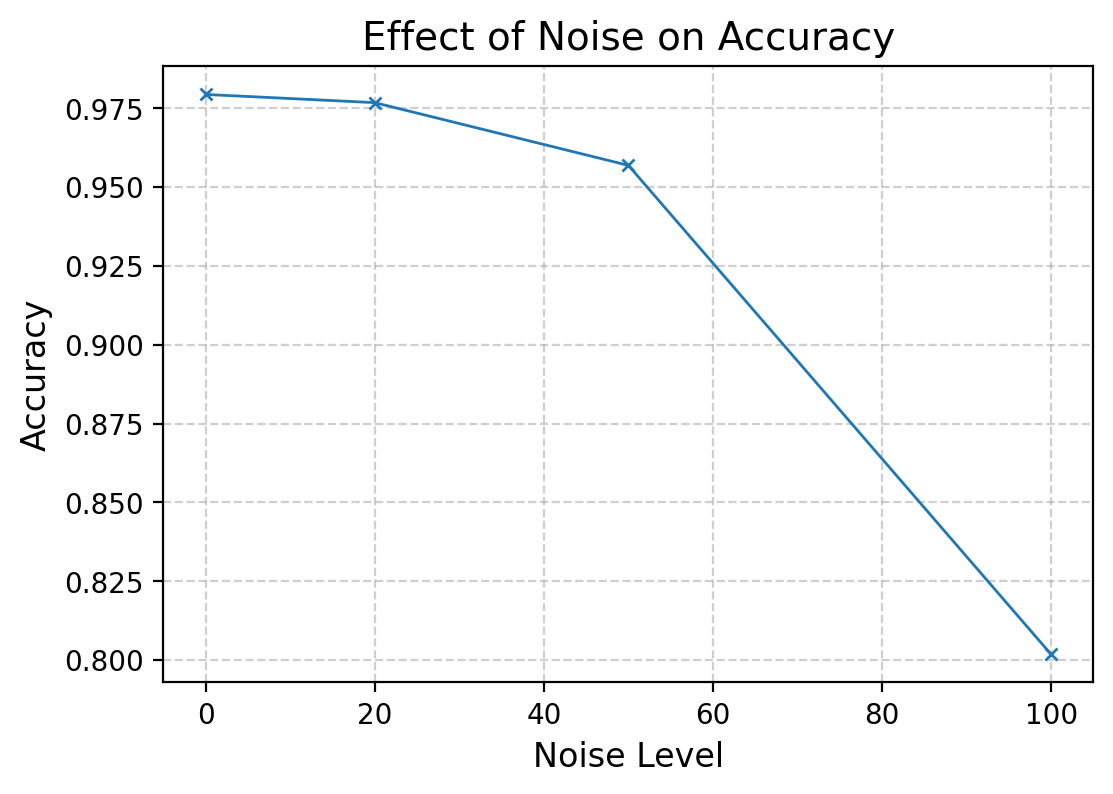

In [40]:
fig, ax = plt.subplots()

ax.plot(yNoises, accuracy_array, linestyle='-', marker='x', markersize=4, linewidth=1)
ax.set_xlabel("Noise Level", fontsize=12)
ax.set_ylabel("Accuracy", fontsize=12)
ax.set_title("Effect of Noise on Accuracy", fontsize=14)
ax.grid(True, linestyle="--", alpha=0.6)

plt.show()


The performance of the neural network trained on clean data deteriorates as noise is introduced. To address this, we will retrain the model using noisy data.



# Retrain the network using noisy training data and re-evaluate

In [15]:

# Define the range of noise levels (from 0 to 200, in 11 steps)
noise_levels = np.linspace(0, 200, 11)

# Initialize an array to store test accuracies for each noise combination
test_accuracies = np.zeros((len(yNoises), len(noise_levels)))

# Initialize an array to store test images with different noise levels
noisy_test_images = np.zeros((len(noise_levels), test_shape[0], test_shape[1], test_shape[2]))

# Copy the original test images as the first entry (zero noise)
noisy_test_images[0] = test_images.copy()

# Apply noise to test images
for i, noise in enumerate(noise_levels):
    noisy_test_images[i] = add_noise_to_images(noise / 255, test_images.copy())  # Normalize noise by 255



In [16]:
# Iterate over different noise levels for training
for i, train_noise in enumerate(yNoises):
    # Create and compile a new model with randomized initial weights
    model_noisy = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),
        keras.layers.Flatten(),
        keras.layers.Dense(128, activation='relu'),
        keras.layers.Dense(10)
    ])

    model_noisy.compile(
        loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
        optimizer=tf.keras.optimizers.SGD(learning_rate=0.2),
        metrics=['accuracy']
    )
    #Adjusted the learning rate to 0.2, as it yielded better results.
    #Previously, using a learning rate of 0.1 caused the model to learn too quickly, leading to inaccuracies—especially when a significant amount of noise was introduced.

    # Generate a new noisy training set
    noisy_train_images = add_noise_to_images(train_noise / 255, train_images.copy())

    # Train the model
    model_noisy.fit(noisy_train_images, train_labels, batch_size=100, epochs=20, verbose=1)

    # Evaluate model performance across different test noise levels
    accuracy_results = np.zeros(len(noise_levels))

    for j, test_noise in enumerate(noise_levels):
        test_loss, test_acc = model_noisy.evaluate(noisy_test_images[j], test_labels, verbose=0)
        accuracy_results[j] = test_acc

    # Store accuracy results
    test_accuracies[i] = accuracy_results


Epoch 1/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8359 - loss: 0.5777
Epoch 2/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9458 - loss: 0.1898
Epoch 3/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - accuracy: 0.9608 - loss: 0.1369
Epoch 4/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9683 - loss: 0.1110
Epoch 5/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9742 - loss: 0.0895
Epoch 6/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9775 - loss: 0.0800
Epoch 7/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.9816 - loss: 0.0653
Epoch 8/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.9828 - loss: 0.0612
Epoch 9/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.9858 - loss: 0.0521
Epoch 10/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9872 - loss: 0.0462
Epoch 11/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9890 - loss: 0.0416
Epoch 12/20
600/600 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step

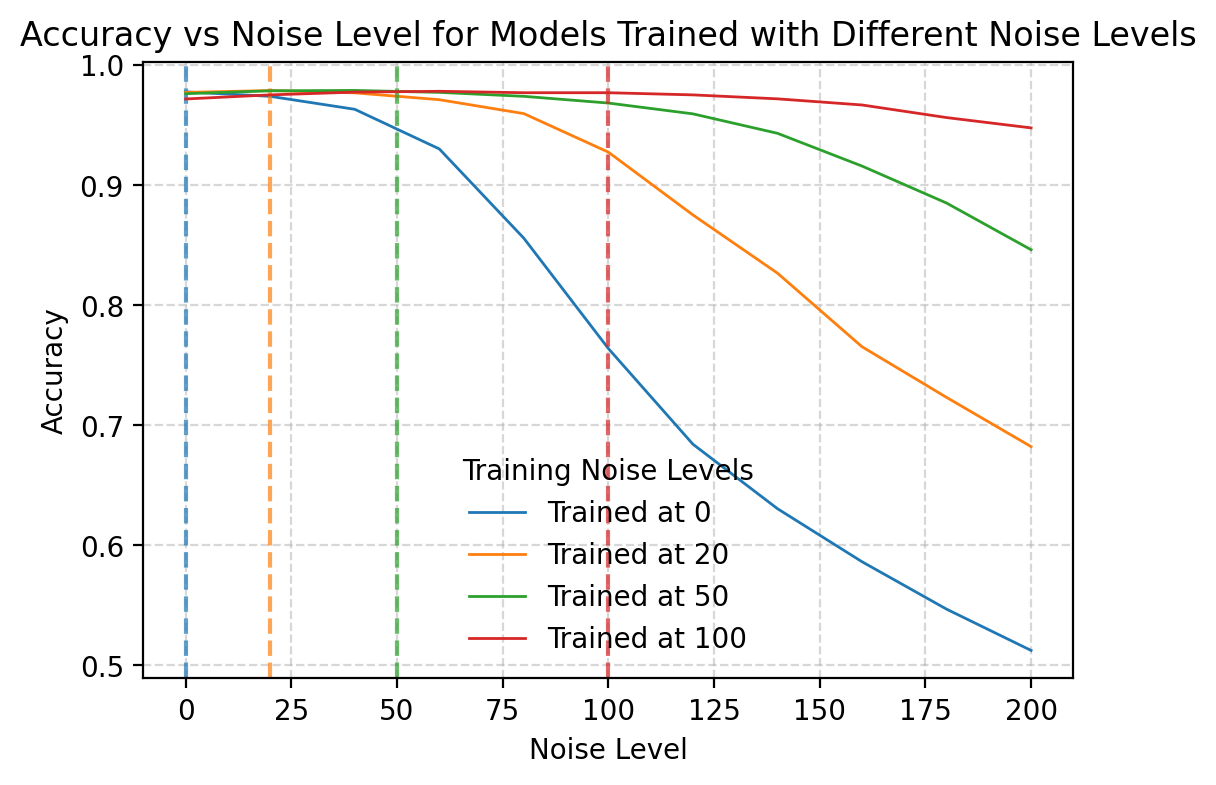

In [36]:
# Define y-axis range for vertical lines
y_min, y_max = 0, 1

# Create the plot
fig, ax = plt.subplots()

# Iterate over different trained noise levels
for i, noise in enumerate(yNoises):
    ax.plot(noise_levels, test_accuracies[i], linewidth=1, label=f'Trained at {noise}', color=f'C{i}')
    ax.axvline(noise, linestyle='--', color=f'C{i}', alpha=0.7)  # Vertical boundary lines

# Set labels and title
ax.set_xlabel("Noise Level")
ax.set_ylabel("Accuracy")
ax.set_title("Accuracy vs Noise Level for Models Trained with Different Noise Levels")

# Add legend and grid
ax.legend(title="Training Noise Levels")
ax.grid(True, linestyle='--', alpha=0.5)

# Show the plot
plt.show()


As the noise level increases during training, the models exhibit higher accuracy across the entire testing dataset, with the model trained at a noise level of 100 performing the best. Interestingly, some models even outperform others on noise levels they were not specifically trained on.

The accuracy of each model tends to peak around the noise level it was trained on before dropping off sharply beyond that point.

Defining performance is context-dependent and varies based on the specific goals of the task. In machine learning, different models may perform better or worse depending on the characteristics of the data they are trained on. For example, some models might excel in environments with low noise, while others perform better when there’s more variability or noise in the data.